# Анализ рынка заведений общественного питания Москвы



### Цели и задачи проекта


**Цель проекта -** провести исследовательский анализ рынка общественного питания Москвы на основе открытых данных о заведениях для выявления закономерностей, влияющих на рейтинг.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Создать новый производный признак круглосуточной работы (is_24_7)
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить взаимосвязь данных в столбце `rating` с другими данными.
4. Сформулировать выводы по проведённому анализу.

### Описание данных


**Файл 'rest_info' содержит информацию о заведениях общественного питания:**

- name — название заведения;
- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный АО;
- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- hours — информация о днях и часах работы;
- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- chain — число, выраженное 0 (не сетевое) или 1(сетевое), которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки).

**Файл 'rest_price' содержит информацию о среднем чеке в заведениях общественного питания:**
- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и т.д.;
- avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона
- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»
- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:


## 1. Загрузка данных и знакомство с ними

Импортируем необходимые для работы библиотеки и загружаем данные о заведениях общественного питания Москвы.

In [1]:
!pip install phik -q 

In [2]:
# Импортируем библиотеки
import pandas as pd

import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import cm

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

!pip install missingno

import missingno as msno

In [3]:
# Выгружаем данные в переменные bank_df и clients_df
info_df = pd.read_csv('/datasets/rest_info.csv')
# Выводим первые строки датафрейма на экран
price_df = pd.read_csv('/datasets/rest_price.csv')

Изучим общую информацию о данных.

In [4]:
# Выводим первые строки датафреймов на экран
display(info_df.head(5))

display(price_df.head(5))

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [5]:
# Выводим информацию о датафреймах
print('Информация о файле с заведениями', '\n')
print(info_df.info())

print('Информация о файле со средним чеков в заведениях', '\n')
print(price_df.info())

Информация о файле с заведениями 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB
None
Информация о файле со средним чеков в заведениях 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bil

---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

**Датасет 'rest_info.csv.'** содержит 9 столбцов и 8406 строк, 
в которых представлена информация о заведениях общественного питания

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов имеет однородную структуру.
- Большенство представленных данных содержат строковые значения и хранятся с типом данных 'object'. 
- Значения в столбцах 'rating', 'chain'и 'seats' представлены числами и имеют тип данных 'float'.
- Значения в столбце'chain' показывает наличие у клиента того или иного признака
  и содержит значения 1 или 0 — размерность этих данных можно оптимизировать.
- Формат времени работы в столбце 'hours' требует дополнительной обработки, 
  в ходе работы с данными выделим параметр круглосуточных заведений.
- Пропуски содержатся только в столбцах 'seats' и 'hours'.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

**Датасет 'rest_price.csv.'** содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов имеют одинаковый вид snake case.
- Столбцы 'id' 'price' 'avg_bill' содержат строковые значения и хранятся с типом данных 'object'.
- Столбцы 'middle_avg_bill' 'middle_coffee_cup' содержат числовые данные и хранятся с типом 'float64'
- Пропуски содержатся в столбцах 'price' 'avg_bill' 'middle_coffee_cup', это естественно, так как данные так как данные указаны не для всех заведений
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

### Подготовка единого датафрейма

Объединим данные двух датасетов в один.

In [6]:
# Объединяем датафреймы через 'left', так как нам необходимо сохранить все заведения
join_df = info_df.merge(price_df, on ='id', how='left')

In [7]:
# Размер объединенного датафрейма
print(join_df.shape)
print(join_df.info())
display(join_df.head(5))

(8406, 13)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB
None


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


### Промежуточный вывод по объединенному датафрейму
**Датафрейм 'join_df'** содержит 13 столбцов и 8406 строк, 
в которых представлена информация о заведениях общественного питания и среднем чеке в этих заведениях

Пропуски:
- в столбце 'hours' количество пропусков меньше 10%
- в столбцах 'seats', 'price', 'middle_avg_bill' количество пропусков больше половины
- в стобце 'middle_coffee_cup' - максимальное количество пропусков, более 90%


## 2. Предобработка данных

Изучим корректность типов данных и при необходимости проведем их преобразование.

In [8]:
# Проверяем типы данных

print('Типы данных')
print(join_df.dtypes)

Типы данных
id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object


In [9]:
# Оптимизируем столбец chain
# join_df['chain'] = join_df['chain'].astype('int32')

# Оптимизация числовых типов данных
def optimize_memory_usage(df: pd.DataFrame, print_size: bool=True) -> pd.DataFrame:
    '''
    Function optimizes memory usage in dataframe
    df: pd.DataFrame - data table
    print_size: bool - display of optimization results
    return pd.DataFrame - amount of optimized memory
    '''
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64'] # Типы, которые будем проверять на оптимизацию
    # Размер занимаемой памяти до оптимизации (в Мб)
    before_size = df.memory_usage().sum() / 1024**2    
    for column in df.columns:
        column_type = df[column].dtypes
        if column_type in numerics:
            column_min = df[column].min()
            column_max = df[column].max()
            if str(column_type).startswith('int'):
                if column_min > np.iinfo(np.int8).min and column_max < np.iinfo(np.int8).max:
                    df[column] = df[column].astype(np.int8)
                elif column_min > np.iinfo(np.int16).min and column_max < np.iinfo(np.int16).max:
                    df[column] = df[column].astype(np.int16)
                elif column_min > np.iinfo(np.int32).min and column_max < np.iinfo(np.int32).max:
                    df[column] = df[column].astype(np.int32)
                elif column_min > np.iinfo(np.int64).min and column_max < np.iinfo(np.int64).max:
                    df[column] = df[column].astype(np.int64)  
            else:
                if column_min > np.finfo(np.float32).min and column_max < np.finfo(np.float32).max:
                    df[column] = df[column].astype(np.float32)
                else:
                    df[column] = df[column].astype(np.float64)    
    # Размер занимаемой памяти после оптимизации (в Мб)
    after_size = df.memory_usage().sum() / 1024**2
    if print_size: print('Размер использования памяти: до {:5.2f} Mb - после {:5.2f} Mb ({:.1f}%)'
                         .format(before_size, after_size, 100 * (before_size - after_size) / before_size))
    return df

join_df = optimize_memory_usage(join_df)

Размер использования памяти: до  0.90 Mb - после  0.71 Mb (20.5%)


In [10]:
print('Типы данных')
print(join_df.dtypes)

Типы данных
id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                float32
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object


На данном этапе оптимизировали размерность данных в столбцах: rating, chain, seats, middle_avg_bill, middle_coffee_cup                  

Столбцы rating, seats, middle_avg_bill, middle_coffee_cup имеют тип данных float, так как содержат пропуски, количество пропусков значительное

Изучим пропущенные значения в данных, проведем обработку пропущенных значений.

In [11]:
# Применяем метод isna() 
missing_raw = join_df.isna().sum()

# Подсчитываем долю строк с пропусками
missing_percent = round((join_df.isna().sum() / join_df.shape[0]),2)*100

missing_data = pd.DataFrame ({
    'Абсолютное значение': missing_raw,
    'Относительное значение': missing_percent
})

print('Пропущенные значения')
display(missing_data)

Пропущенные значения


,Абсолютное значение,Относительное значение
id,0,0.0
name,0,0.0
category,0,0.0
address,0,0.0
district,0,0.0
hours,536,6.0
rating,0,0.0
chain,0,0.0
seats,3611,43.0
price,5091,61.0


- hours - пропуски 6%, эти данные не критичны для анализа, оставим, как есть
- seats - большое количество пропусков, удалять их не стоит
- price avg_bill 	middle_avg_bill	middle_coffee_cup - пропусков больше половины, но они естественны, цены могут быть указаны не везде, из-за этого ценовая категлория тооже содержит пропуски

<Figure size 720x432 with 0 Axes>

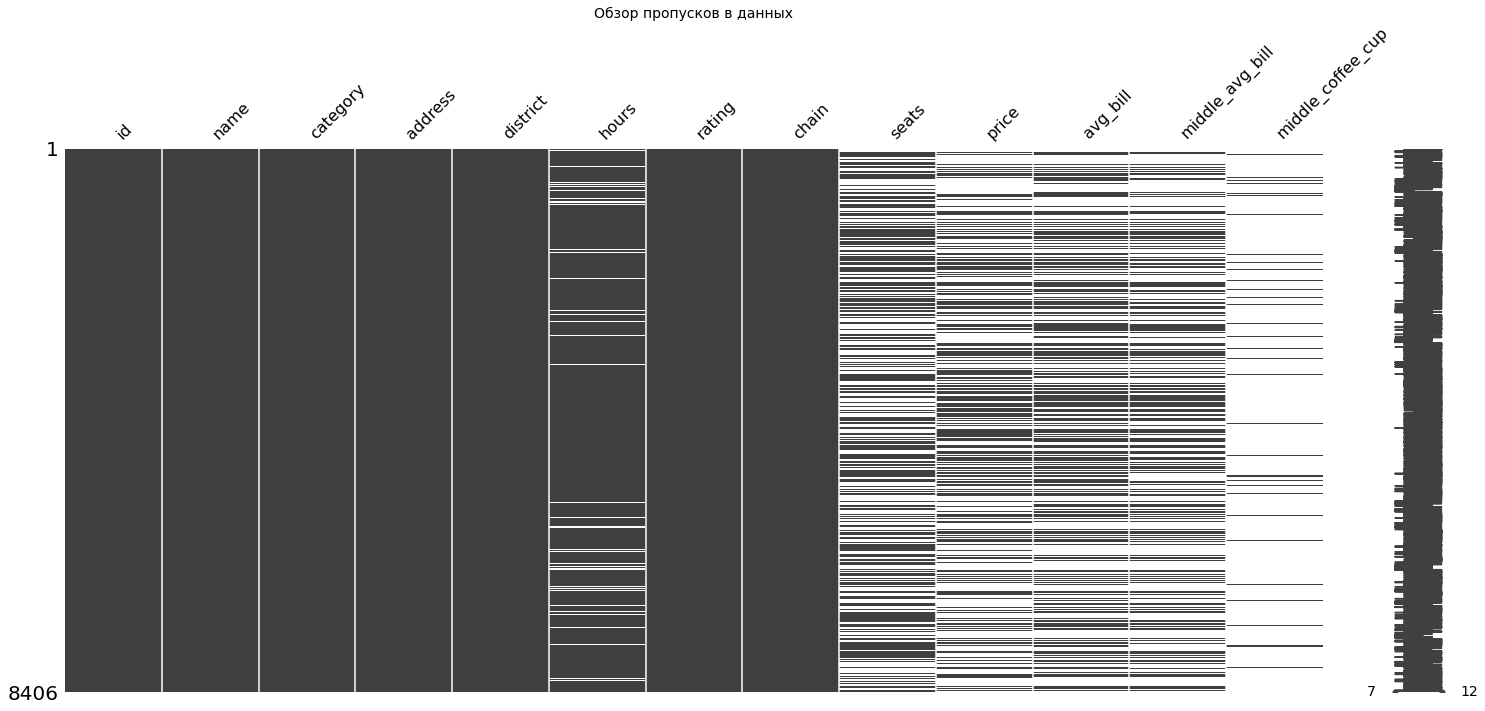

In [12]:
# Визуализация пропусков
plt.figure(figsize = (10,6))
msno.matrix(join_df)

plt.title('Обзор пропусков в данных', fontsize = 14)

plt.show()

<Figure size 576x432 with 0 Axes>

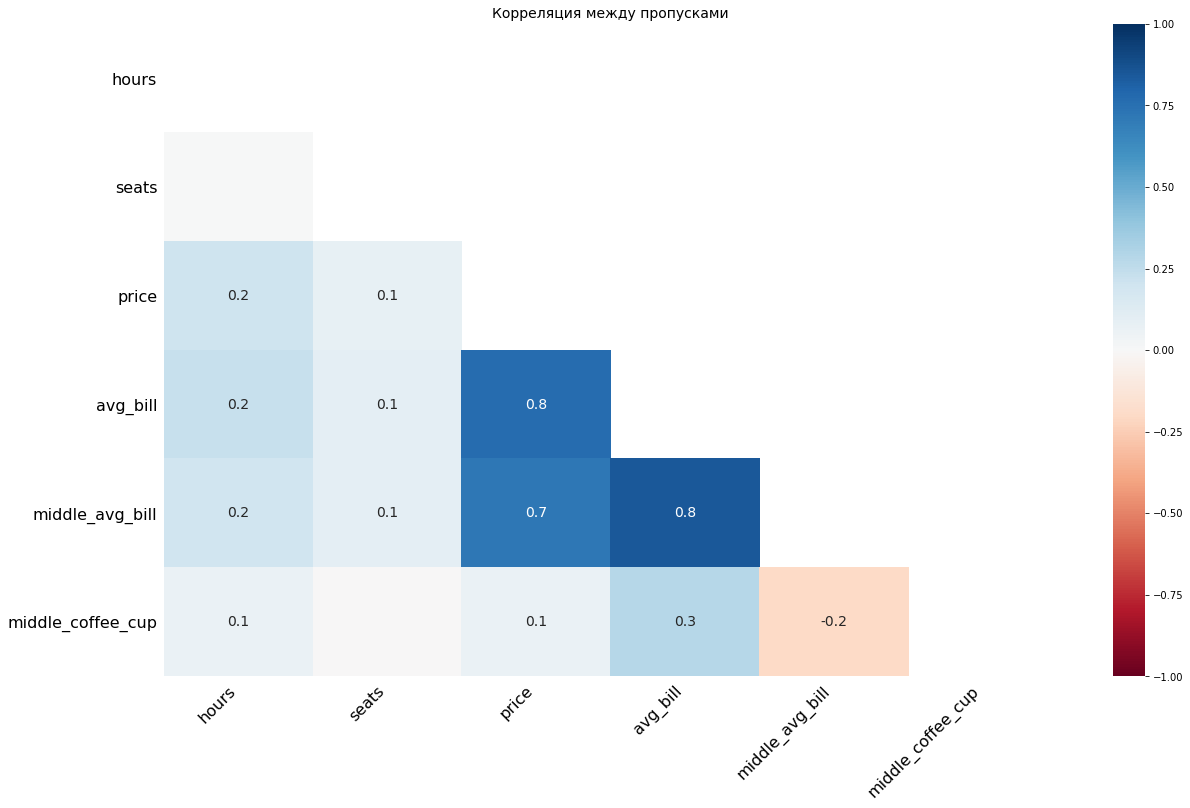

In [13]:
# Корреляция между пропусками
plt.figure(figsize =(8,6))
msno.heatmap(join_df)
plt.title('Корреляция между пропусками', fontsize=14)

plt.show()

Первый график визуализирует пропуски и заполненность данных
Второй график представляет собой матрицу корреляций между количественными признаками.
Выводы, которые можно сделать:
- в данных много пропусков по важным числовым признакам, это ограничивает качество анализа
- видна сильная положительная корреляция между показателями среднего чека, так как столбцы middle_coffee_cup и middle_avg_bill появились после парсинга столбца avg_bill

In [14]:
# Выведем честь датафрейма и информацию о нем

print(join_df.info())
display(join_df.head(5))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(4), int8(1), object(8)
memory usage: 730.6+ KB
None


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


Проверим данные на явные и неявные дубликаты, например поля с названием и адресом заведения. 

In [15]:
# Приведение столбцов 'name','address', 'district' к нижнему регистру
text_columns = ['name','address', 'district']

for col in text_columns:
    if col in join_df.columns:
        join_df[col]=(
            join_df[col].astype(str).str.lower())
        
display(join_df.head(5))

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [16]:
# Проверяем полные дубликаты в датафрейме
join_df.duplicated().sum()

0

В датафрейме нет полных дубликатов строк. Проверим неявные дубликаты — значения по id клиентов должны быть уникальными, то есть каждая строка в данных — уникальный клиент:

In [17]:
# Проверяем неявные дубликаты в датафрейме 
join_df.duplicated(subset='id').sum()

0

Тут тоже всё хорошо — каждая строка соответствует уникальному клиенту.

Дополнительно проведем анализ по столбцам название заведения и адрес.

In [18]:
# Проверяем строки с одинаковыми адресом и названием 
dublicates = join_df[join_df.duplicated(subset=['name','address'], keep = False)]


display(dublicates)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN


Поиск дубликатов по двум параметрам выявило задвоение некоторых заведений. 
Разберем пары значений:
- Название 'кафе'  в категории кафе отличаются только одним пареметром - временем работы 
- Название 'more poke' в категории ресторан отличается двумя параметрами- временем работы и принадлежностью к сети (в описании данных была информация, об ошибкав в столбце chain для маленьких заведений)
- Название 'раковарня клешни и хвосты' принадлежит к разным категориям ресторан и бар, второй столбец, который отличается - время работы, третий столбец принадлежность к сети 
- Название 'хлеб да выпечка' также отличается тремя параметрами - категория (булочная или кафе), временем работы и принадлежностью к сети

Вероятность того, что на одном адресе находятся два заведения с одинаковым названием крайне мала. По этому удалим повторяющиеся значенния, выбрав строки, где информация более развернута

In [19]:
# Удаляем дубликаты, оставив только уникальные записи
idx = join_df.groupby(['name','address'])['chain'].idxmax()
join_df = join_df.loc[idx].reset_index(drop=True)
print(join_df.info())
display(join_df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8402 entries, 0 to 8401
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             8402 non-null   float32
 7   chain              8402 non-null   int8   
 8   seats              4792 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(4), int8(1), object(8)
memory usage: 664.7+ KB
None


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,1beedf65579a479dbfc8e4aa19841421,#кешбэккафе,кафе,"москва, большая татарская улица, 11с",центральный административный округ,пн-пт 09:00–17:00,4.0,0,NaN,NaN,NaN,NaN,NaN
1,9f5119fd1f5c4d8b8c09b6bd4a823221,+39 pizzeria mozzarella bar,пиццерия,"москва, столярный переулок, 3, корп. 12",центральный административный округ,"пн-чт 12:00–22:00; пт,сб 12:00–23:00; вс 12:00...",4.8,0,NaN,NaN,NaN,NaN,NaN
2,cb3f4fb76f144583b7ce0fa523c9ffc9,1 этаж,кафе,"москва, улица костякова, 6/5",северный административный округ,"ежедневно, 10:00–23:00",4.3,0,40.0,NaN,NaN,NaN,NaN
3,45e2e7bff6184d7191493867674ee5e7,1-я креветочная,кафе,"москва, мячковский бульвар, 3а",юго-восточный административный округ,"пн-чт 10:00–21:00; пт,сб 10:00–22:00; вс 10:00...",3.7,1,0.0,NaN,NaN,NaN,NaN
4,f44f7e48e5d6423fb432a88549f3040c,10 идеальных пицц,ресторан,"москва, улица большие каменщики, 9се",центральный административный округ,"ежедневно, 11:45–22:30",4.3,1,NaN,NaN,NaN,NaN,NaN


После удаления диблирующих строк размерность датаврейма составила 8402 строки и 13 столбцов

Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в ином случае.

In [20]:
# Добавляем столбец для определения кругласуточной и ежедневной работы заведения
join_df['is_24_7'] = join_df['hours'].apply(
    lambda x: True if isinstance(x, str) and ('круглосуточно' in x and 'ежедневно' in x)
    else False)

print(join_df.info())
display(join_df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8402 entries, 0 to 8401
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             8402 non-null   float32
 7   chain              8402 non-null   int8   
 8   seats              4792 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
 13  is_24_7            8402 non-null   bool   
dtypes: bool(1), float32(4), int8(1), object(8)
memory usage: 672.9+ KB
None


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,1beedf65579a479dbfc8e4aa19841421,#кешбэккафе,кафе,"москва, большая татарская улица, 11с",центральный административный округ,пн-пт 09:00–17:00,4.0,0,NaN,NaN,NaN,NaN,NaN,False
1,9f5119fd1f5c4d8b8c09b6bd4a823221,+39 pizzeria mozzarella bar,пиццерия,"москва, столярный переулок, 3, корп. 12",центральный административный округ,"пн-чт 12:00–22:00; пт,сб 12:00–23:00; вс 12:00...",4.8,0,NaN,NaN,NaN,NaN,NaN,False
2,cb3f4fb76f144583b7ce0fa523c9ffc9,1 этаж,кафе,"москва, улица костякова, 6/5",северный административный округ,"ежедневно, 10:00–23:00",4.3,0,40.0,NaN,NaN,NaN,NaN,False
3,45e2e7bff6184d7191493867674ee5e7,1-я креветочная,кафе,"москва, мячковский бульвар, 3а",юго-восточный административный округ,"пн-чт 10:00–21:00; пт,сб 10:00–22:00; вс 10:00...",3.7,1,0.0,NaN,NaN,NaN,NaN,False
4,f44f7e48e5d6423fb432a88549f3040c,10 идеальных пицц,ресторан,"москва, улица большие каменщики, 9се",центральный административный округ,"ежедневно, 11:45–22:30",4.3,1,NaN,NaN,NaN,NaN,NaN,False


Мы добавили новый категорийный столбец с признаком кругласуточной и ежедневной работы заведений. Проверили корректность отображения информации, выведя несколько строк датафрейма и информацию и нем.

---

### Промежуточный вывод


В результате предобработки данных были выполнены следующие действия:

- В столбцах seats и chain изменен тип данных на int32
- Изучены пропуски в данных. Пропуски обнаружились в столбцах hours (6%) seats (43%) price (61%)  avg_bill (55%) middle_avg_bill (63%)	middle_coffee_cup (94%).
- В столбце seats пропущено около половины данных, пропуски были заменены медианой по каждой категории заведений.
- Пропуски в столбце hours сохранены, так как отутсвие графика работы
- Учитывая большое количество пропусков в столбцах с ценами, пропуски отражают отсутствие информации о чеке в части заведений и не являться ошибкой в данных. Поэтому их оставили как есть.
- Создан новый признак is_24_7, отражающий факт кругласуточной и ежедневной работы заведения 
- Данные проверили на явные и неявные дубликаты — в данных их нет.

**Общий вывод:**

После предобработки данные очищены, типы данных приведени и оптимизированы, обработаны пропуски.
Итоговый датафрейм готов к проведению анализа и построению визуализаций. 

## 3. Исследовательский анализ данных

Проведем исследовательский анализ исходных данных.


---

###  Категории заведений, прадставленные в данных

Исследуем количество объектов общественного питания по каждой категории.

In [21]:
# Подсчет кол-ва заведений по категориям 
category_counts = join_df['category'].value_counts().sort_values(ascending = False)

# Расчет процентного соотношения распределения заведений по категориям
category_percent = join_df['category'].value_counts(normalize=True).sort_values(ascending = False)

category_result = pd.DataFrame({
    'Абсолютные значения': category_counts,
    'Относительные значения': category_percent.round(2)
})
display(category_result)


,Абсолютные значения,Относительные значения
кафе,2376,0.28
ресторан,2041,0.24
кофейня,1413,0.17
"бар,паб",765,0.09
пиццерия,633,0.08
быстрое питание,603,0.07
столовая,315,0.04
булочная,256,0.03


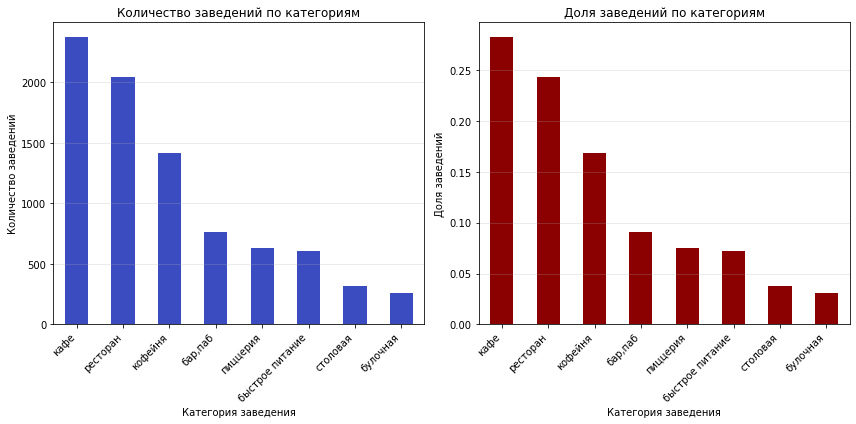

In [22]:
# Создаем фигуру и два подграфика
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Первый график
category_counts.plot(kind='bar', ax=ax1, color='#3b4cc0')
ax1.set_title('Количество заведений по категориям')
ax1.set_xlabel('Категория заведения')
ax1.set_ylabel('Количество заведений')
ax1.set_xticklabels(category_counts.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Второй график
category_percent.plot(kind='bar', ax=ax2, color='#8b0000')
ax2.set_title('Доля заведений по категориям')
ax2.set_xlabel('Категория заведения')
ax2.set_ylabel('Доля заведений')
ax2.set_xticklabels(category_percent.index, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Настраиваем макет
plt.tight_layout()

# Показываем графики
plt.show()



После анализа  было выявлено, что в Москве представлено несколько основных категорий заведений общественного питания. Наиболее многочисленными оказались кафе и рестораны - они составляют значительную долю рынка
Также широко распространены кофейни, менее булочные и столовые.
Это может свидетельствовать о том, что рынок в первую очередь ориентирован на формат повседневного питания

---

### Административные районы Москвы, присутствующие в данных

Проанализируем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

In [23]:
# Подсчет количества заведений по округам
district_counts = join_df['district'].value_counts().sort_values(ascending = False)

# Расчет процентного соотношения распределения заведений по округам
district_percent = join_df['district'].value_counts(normalize=True).sort_values(ascending = False)

district_result = pd.DataFrame({
    'Абсолютные значения': district_counts,
    'Относительные значения': district_percent.round(2)
})

display(district_result)


,Абсолютные значения,Относительные значения
центральный административный округ,2242,0.27
северный административный округ,898,0.11
южный административный округ,892,0.11
северо-восточный административный округ,890,0.11
западный административный округ,850,0.10
восточный административный округ,798,0.09
юго-восточный административный округ,714,0.08
юго-западный административный округ,709,0.08
северо-западный административный округ,409,0.05


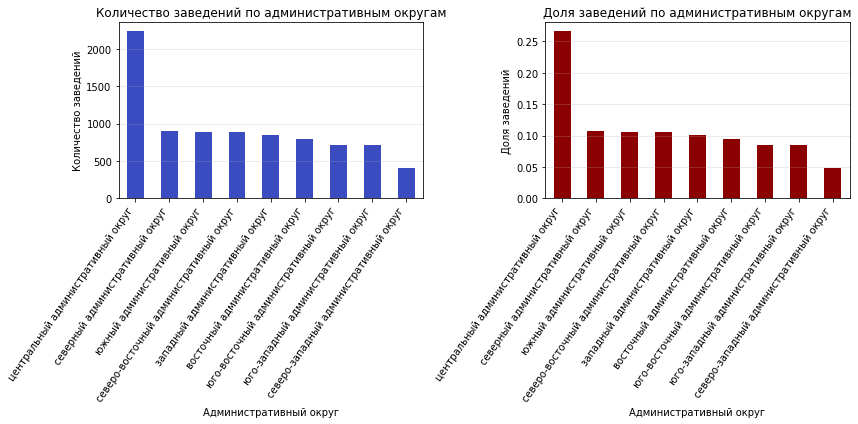

In [24]:
# Создаем фигуру и два подграфика
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Первый график
district_counts.plot(kind='bar', ax=ax1, color='#3b4cc0')
ax1.set_title('Количество заведений по административным округам')
ax1.set_xlabel('Административный округ')
ax1.set_ylabel('Количество заведений')
ax1.set_xticklabels(district_counts.index, rotation=55, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Второй график
district_percent.plot(kind='bar', ax=ax2, color='#8b0000')
ax2.set_title('Доля заведений по административным округам')
ax2.set_xlabel('Административный округ')
ax2.set_ylabel('Доля заведений')
ax2.set_xticklabels(district_percent.index, rotation=55, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Настраиваем макет
plt.tight_layout()

# Показываем графики
plt.show()

Распределение заведений по административным округам Москвы показывает, что почти четверть заведений сконцентрирована в Центральном округе, это объясняется высокой плотностью населения, концентрацией деловой и туристической активности. 
Меньше всего заведений расположено в Северо-западном округе, вероятно, там больше доля жилых объектов и меньше деловых центорв, чем в центре
Распределение заведений в остальных округах города относительно равномерное и находится в диапозоне 700-900 заведений. 

In [25]:
# Отбираем заведения по Центральному административному округу
cao_df =  join_df[join_df['district'].str.contains('центральный', case = True, na = False)]

# Подсчет количества заведений по атегориям в Центральном административном округе
cao_counts = cao_df['category'].value_counts().sort_values(ascending = False)

# Расчет процентного соотношения распределения заведений по ЦАО 
cao_percent = cao_df['category'].value_counts(normalize=True).sort_values(ascending = False)

cao_result = pd.DataFrame({
    'Абсолютные значения': cao_counts,
    'Относительные значения': cao_percent.round(2)
})
display(cao_result)

,Абсолютные значения,Относительные значения
ресторан,670,0.30
кафе,464,0.21
кофейня,428,0.19
"бар,паб",364,0.16
пиццерия,113,0.05
быстрое питание,87,0.04
столовая,66,0.03
булочная,50,0.02


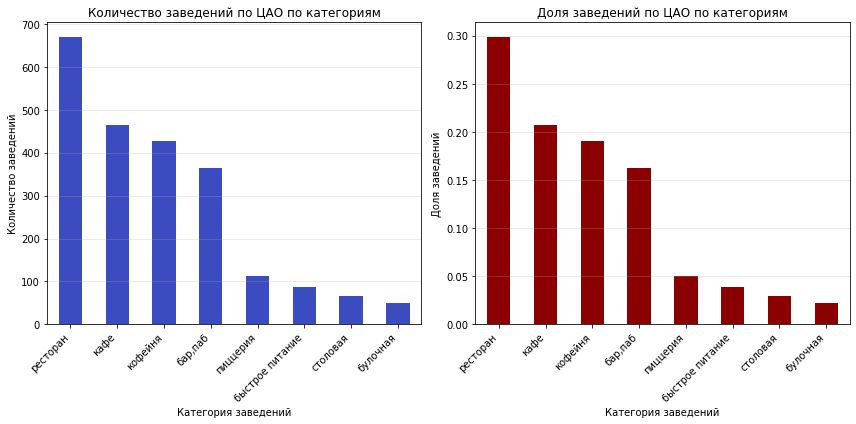

In [26]:

# Создаем фигуру и два подграфика
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Первый график
cao_counts.plot(kind='bar', ax=ax1, color='#3b4cc0')
ax1.set_title('Количество заведений по ЦАО по категориям')
ax1.set_xlabel('Категория заведений')
ax1.set_ylabel('Количество заведений')
ax1.set_xticklabels(cao_counts.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Второй график
cao_percent.plot(kind='bar', ax=ax2, color='#8b0000')
ax2.set_title('Доля заведений по ЦАО по категориям')
ax2.set_xlabel('Категория заведений')
ax2.set_ylabel('Доля заведений')
ax2.set_xticklabels(cao_percent.index, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Настраиваем макет
plt.tight_layout()

# Показываем графики
plt.show()

Отметим,что распределение заведений по категорияв в Центральном административном округе идентично распределению по городу в целом, преобладают также рестораны и кафе, меньшей по количеству заведений категорией является - булочные. Это связано с тем, что центральный округ имеет большой вес в общем распределении и задает для него тенденцию.
Сравнивая относительные показатели распределения заведений по категориям видно, что доля ресторанов в Центральном округе чуть выше (29,88%), чем по Москве в целом (28,29%), что указывает на высокий уровень развития сферы общественного питания в округе. Доля Столовых и булочных в центре напротив ниже, чем по Москве, это может характеризовать особенности спроса в центральном районе.

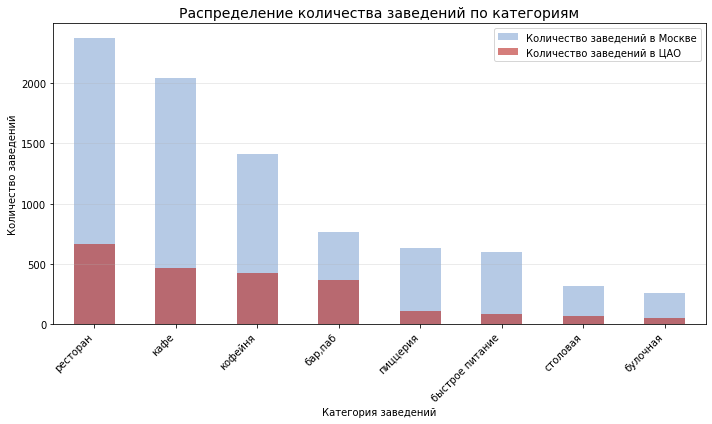

In [27]:
# Визуализация 

plt.figure(figsize = (10,6))
#1 график
category_counts.plot(
    kind = 'bar',
    color = '#86a7d4',
    alpha = 0.6,
    label = 'Количество заведений в Москве')

#2 график
cao_counts.plot(
    kind = 'bar',
    color = '#ba2823',
    alpha = 0.6,
    label = 'Количество заведений в ЦАО')

plt.title ('Распределение количества заведений по категориям', fontsize = 14)
plt.xlabel ('Категория заведений')
plt.ylabel ('Количество заведений')
plt.xticks(rotation = 45, ha='right')
plt.grid(axis = 'y', alpha = 0.3)

plt.legend()
plt.tight_layout()

plt.show()

На графике есть возможность еще раз визуально оценить, какую долю занимают заведения центрального округа в общей массе.
Таким образом, центр остается ключевой зоной концентрации заведений, расчитанных на более высокий средний чек и разнообразную кухню. 

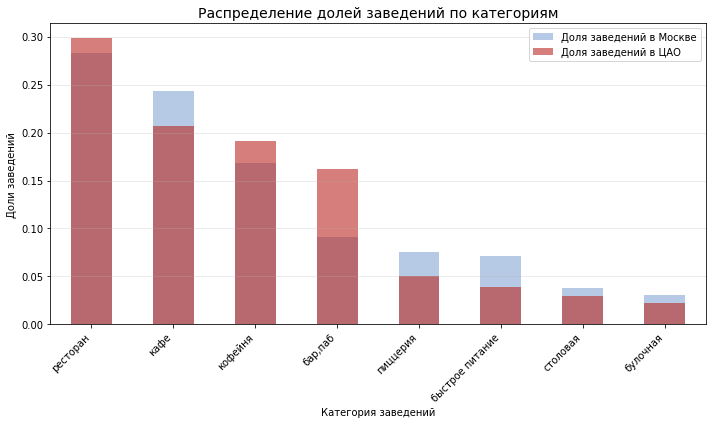

In [28]:

# Визуализация 

plt.figure(figsize = (10,6))
#1 график
category_percent.plot(
    kind = 'bar',
    color = '#86a7d4',
    alpha = 0.6,
    label = 'Доля заведений в Москве')

#2 график
cao_percent.plot(
    kind = 'bar',
    color = '#ba2823',
    alpha = 0.6,
    label = 'Доля заведений в ЦАО')

plt.title ('Распределение долей заведений по категориям', fontsize = 14)
plt.xlabel ('Категория заведений')
plt.ylabel ('Доли заведений')
plt.xticks(rotation = 45, ha='right')
plt.grid(axis = 'y', alpha = 0.3)

plt.legend()
plt.tight_layout()

plt.show()

Отметим, что доли в категориях ресторанов и баров в центральном административном округе превышают доли в этих же категориях по Москве в целом.

---

### Соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения

Выясним, каких заведений больше — сетевых или несетевых и какие категории заведений чаще являются сетевыми

In [29]:
# Подсчет сетевых и несетевых заведений
chain_counts = join_df['chain'].value_counts()

print(chain_counts)

0    5197
1    3205
Name: chain, dtype: int64


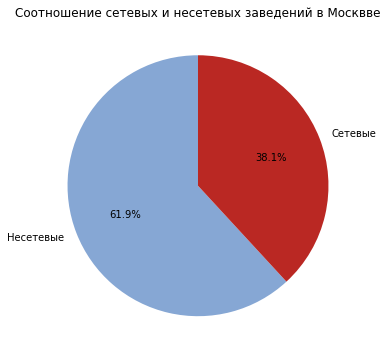

In [30]:
# Визуализация

plt.figure(figsize =(6,6))
plt.pie(chain_counts, 
        labels=['Несетевые','Сетевые'], 
        autopct = '%1.1f%%', 
        startangle = 90, 
        colors=['#86a7d4','#ba2823'])
plt.title('Соотношение сетевых и несетевых заведений в Москвве')

plt.show()

На графике показано соотношение сетевых и несетевых заведений в Москве

Доля несетевых заведений в составляет 61,9%, это свидетельствует о том, что большенство заведений в городе являются независимыми и не принадлежат к крупным сетям

Доля сетевых заведений занимает 38,1% рынка. Это указывает на значительное присутсвие крупных сетей

Такой баланс может говорить о популярности уникальных концепций в несетевых заведениях, в то же время сетевые заведения привлекательны стабильностью.
При планировании открытия заведения необходимо учитывать эту тенденцию, чтобы оценить, какой формат будет более успешным.

In [31]:
# Доля сетевых заведений
chain_by_category = join_df.groupby('category')['chain'].agg(['count','sum'])

# Добавляем два столбца в таблицу 
chain_by_category['percent_chain'] = round((chain_by_category['sum']/chain_by_category['count']*100),2)
chain_by_category['percent_no_chain'] = 100-(round((chain_by_category['sum']/chain_by_category['count']*100),2))

chain_by_category=chain_by_category.sort_values('percent_chain', ascending = False)
print(chain_by_category)

                 count    sum  percent_chain  percent_no_chain
category                                                      
булочная           256  157.0          61.33             38.67
пиццерия           633  330.0          52.13             47.87
кофейня           1413  720.0          50.96             49.04
быстрое питание    603  232.0          38.47             61.53
ресторан          2041  730.0          35.77             64.23
кафе              2376  779.0          32.79             67.21
столовая           315   88.0          27.94             72.06
бар,паб            765  169.0          22.09             77.91


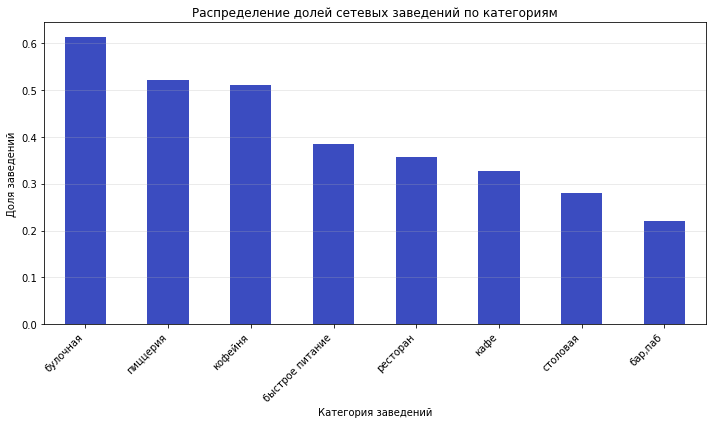

In [32]:
# Подсчитаем долю сетевых заведений
chain_category_percent = join_df.groupby('category')['chain'].mean().sort_values(ascending = False)

# Визуализация
plt.figure(figsize = (10,6))
chain_category_percent.plot(kind = 'bar', color='#3b4cc0')

plt.title('Распределение долей сетевых заведений по категориям')
plt.xlabel('Категория заведений')
plt.ylabel('Доля заведений')
plt.xticks (rotation = 45, ha = 'right')
plt.grid(axis = 'y', alpha = 0.3)
plt.tight_layout()

plt.show()

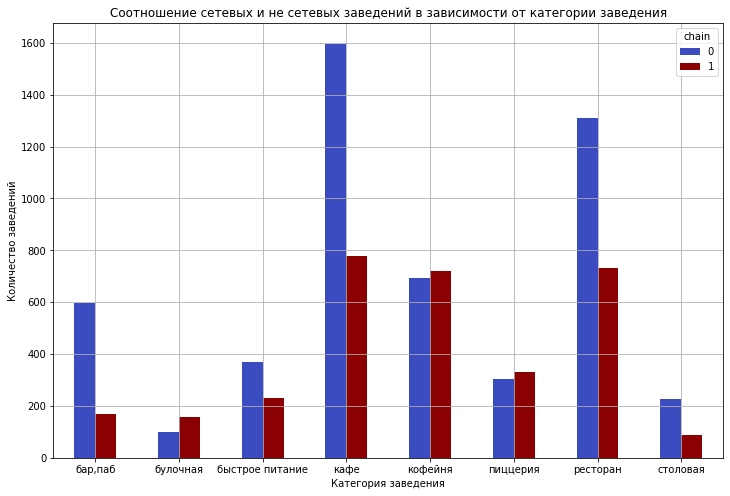

In [33]:
# Построим график столбчатой диаграммы
grouped_chain = join_df.groupby('category')['chain'].value_counts().unstack(fill_value=0)

grouped_chain.plot(kind='bar',
               title=f'Соотношение сетевых и не сетевых заведений в зависимости от категории заведения',
               legend=True,
               ylabel='Количество заведений',
               xlabel='Категория заведения',
               rot=0,
               color=['#3b4cc0','#8b0000'],
               figsize=(12, 8))
plt.grid()

plt.show()


На графике видно, что большая часть заведений общественного питания относится к несетевым - таких заведений в городе почти в два раза больше. Это естественно, так как в Москве широко распространены независимые кафе, рестораны и бары, ориентированные на локальную аудиторию, уникальную кухню или атмосферу.

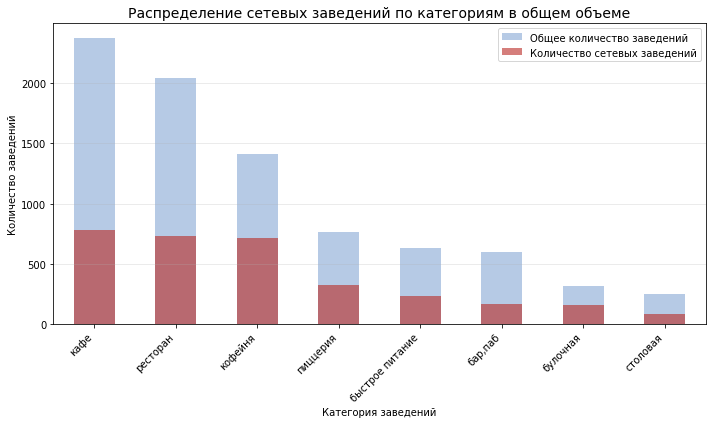

In [34]:
# Подсчитаем общее количество заведений и количество сетевых заведений по категориям

category_chain_count = join_df.groupby('category')['chain'].count().sort_values(ascending = False)
category_chain_sum = join_df.groupby('category')['chain'].sum().sort_values(ascending = False)


plt.figure(figsize = (10,6))

#1 график
category_chain_count.plot(
    kind = 'bar',
    color = '#86a7d4',
    alpha = 0.6,
    label = 'Общее количество заведений')

#2 граафик
category_chain_sum.plot(
    kind = 'bar',
    color = '#ba2823',
    alpha = 0.6,
    label = 'Количество сетевых заведений')

plt.title ('Распределение сетевых заведений по категориям в общем объеме', fontsize = 14)
plt.xlabel ('Категория заведений')
plt.ylabel ('Количество заведений')
plt.xticks(rotation = 45, ha='right')
plt.grid(axis = 'y', alpha = 0.3) 

plt.legend()
plt.tight_layout()

plt.show() 

Сетевые заведения составляют значительно меньшую долю, но вместе с тем демонстрируют стабильное присутствие. Больше всего к сетевому формату склонны следующие категории: булочные (61,33%), пицерии (52,13%) и кофейни (50,96%)

В целом структура рынка отражает тенденцию: чем проще формат заведения и стандартнее меню, тем вероятнее, что заведение является частью сети


---

### Исследуем количество посадочных мест в заведениях

Выясним, встречаются ли в данных аномальные значения или выбросы. Для каждой категории заведений выясним наиболее типичное количество посадочных мест.

In [35]:
join_df.describe()

,rating,chain,seats,middle_avg_bill,middle_coffee_cup
count,8402.000000,8402.000000,4792.000000,3149.000000,535.000000
mean,4.230017,0.381457,108.361435,958.053650,174.721497
std,0.470320,0.485773,122.841133,1009.732849,88.951103
min,1.000000,0.000000,0.000000,0.000000,60.000000
25%,4.100000,0.000000,40.000000,375.000000,124.500000
50%,4.300000,0.000000,75.000000,750.000000,169.000000
75%,4.400000,1.000000,140.000000,1250.000000,225.000000
max,5.000000,1.000000,1288.000000,35000.000000,1568.000000


Вывод по датафрейму: 
- Рейтинг. Среднее значение 4.23, разброс небольшой (0.47), что говорит о высокой средней оценки заведений
- Сетевой признак. Среднее близко к 0 (0.38), медиана тоже 0, большенство заведений - не сетевые, лишь небольшая часть входит в сеть
- Количество мест. Среднее 108, но высокий разброс (стандартное отклонение 123) и большой диапозон от 0 до 1288 мест, 75% заведений имеют до 140 мест
- Средний чек. Среднее около 958 руб., значительное отклонение (1009руб.), минимум -0 руб., максимум- 35000 руб., медиана при этом 750 руб.. Это может указывали как на ошибки в данных, так и на очень дороги заведения
- Средняя цена чашки кофе. Среднее 174 руб., стандартное отклонение 88 руб., медиана - 165 руб., максимум - 1568 руб. Большая часть заведений продает кофе ниже среднего значения, но есть и дорогие предложения.

Еще раз отметим наличае пропусков в столбцах, что можно видеть по значению count.

Для качественного анализа стоит обратить внимание на выбросы.


Рассмотрим количество посадочных мест подробнее 

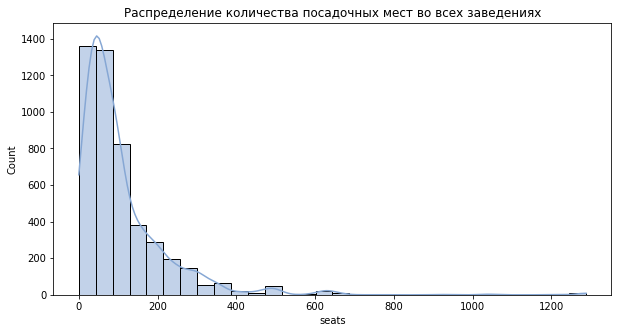

In [36]:
# Гистограмма распределения
plt.figure(figsize = (10,5))
sns.histplot(join_df['seats'], bins=30, kde=True, color='#86a7d4')
plt.title('Распределение количества посадочных мест во всех заведениях')
plt.show()

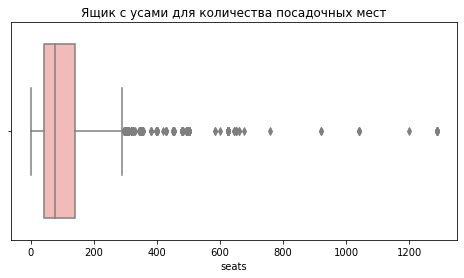

In [37]:
# Проверка выбросов. Построим ящик с усами
plt.figure(figsize=(8,4))
sns.boxplot(x=join_df['seats'], palette = 'Pastel1')
plt.title('Ящик с усами для количества посадочных мест')
plt.show()

In [38]:
# Выведем строки с выбросами
join_df[join_df['seats']>join_df['seats'].quantile(0.99)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
81,0b8062d352c84a65bca70622eecbc745,alternative coffee,кофейня,"москва, проспект вернадского, 41, стр. 1",западный административный округ,"пн-пт 09:00–21:00; сб,вс 09:00–22:00",4.3,0,1288.0,NaN,NaN,NaN,NaN,False
707,fbf22d98b62a47fbb2a71be3545f16b2,delonixcafe,ресторан,"москва, проспект вернадского, 94, корп. 1",западный административный округ,"ежедневно, круглосуточно",4.1,0,1288.0,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN,True
796,77141ea2e18e4f06867b6fef81f2aae4,eataly,"бар,паб","москва, киевская улица, 2",западный административный округ,"ежедневно, 12:00–23:00",4.6,0,920.0,NaN,NaN,NaN,NaN,False
905,405d22c88ca742d39409563ee6cf2be6,for your kids,кафе,"москва, мичуринский проспект, 58, корп. 1",западный административный округ,NaN,3.3,0,650.0,NaN,NaN,NaN,NaN,False
1333,ba5a32dfee6c4661a25c0ea2d39f393d,loft-cafe академия,кафе,"москва, проспект вернадского, 84, стр. 1",западный административный округ,пн-пт 09:00–20:00; сб 09:00–16:00,3.6,0,1288.0,NaN,NaN,NaN,NaN,False
1358,d614bdfe5e144e228ab874b745437452,lyanson’s coffee,кафе,"москва, мичуринский проспект, 27, корп. 1",западный административный округ,пн-пт 08:00–20:00,3.8,0,650.0,NaN,NaN,NaN,NaN,False
1596,0508ba663a4c42d1b5068e51afcc26ef,one price coffee,кофейня,"москва, проспект вернадского, 84, стр. 1",западный административный округ,"ежедневно, 08:30–20:00",4.3,1,1288.0,NaN,NaN,NaN,NaN,False
2188,6fe9438c3572417eab3c676ec81ef494,the fox pub,"бар,паб","москва, мичуринский проспект, 22, корп. 1",западный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.7,0,650.0,NaN,NaN,NaN,NaN,False
2318,761ed3e64f354902b11d7bb95da75e1b,vibes cafe,кафе,"москва, улица миклухо-маклая, 6",юго-западный административный округ,пн-пт 09:00–20:00; сб 09:00–16:00,4.4,0,644.0,NaN,NaN,NaN,NaN,False
3075,8d07e2d1810b4dca9d4cb247d0335df3,ваня и гоги,"бар,паб","москва, измайловское шоссе, 71, корп. а",восточный административный округ,"ежедневно, 11:00–06:00",4.2,0,1040.0,высокие,Средний счёт:1000–2500 ₽,1750.0,NaN,False


Основные наблюдения по графикам:
- Медианное значение по общей выборке около 80, ниже рассмотрим этот показатель более подробно в разрезе категорий заведения
- Заметим, что распределение посадочных мест сильно смещено вправо - большенство заведений имеют до 200 пасадочных мест, но есть отдельные заведения с более чем 1000 мест
- При проверке через ящик с усами, можно увидеть наличае аномальных выбросов. Значения 800-1000 мест встречаются редко, скорее, они связаны с ошибками в  данных, но есть вероятность существования заведений с крупными банкетными залами, фудкортов с большим количеством мест и прочих площадок.

In [39]:
# Расчитаем медианное количество мест по типам заведений
join_df.groupby('category')['seats'].median().sort_values(ascending = False)

category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float32

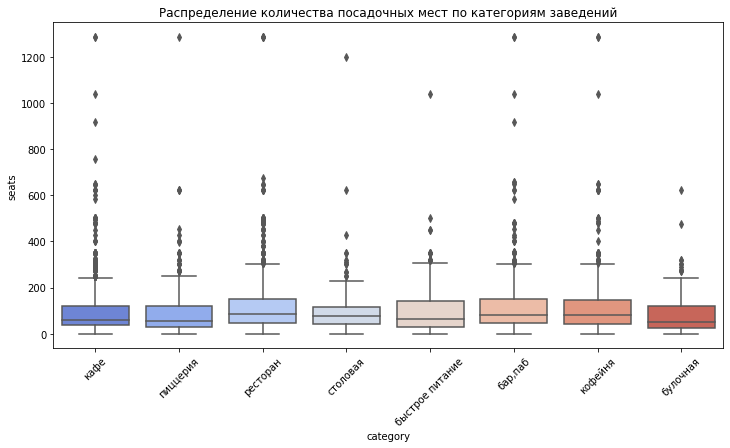

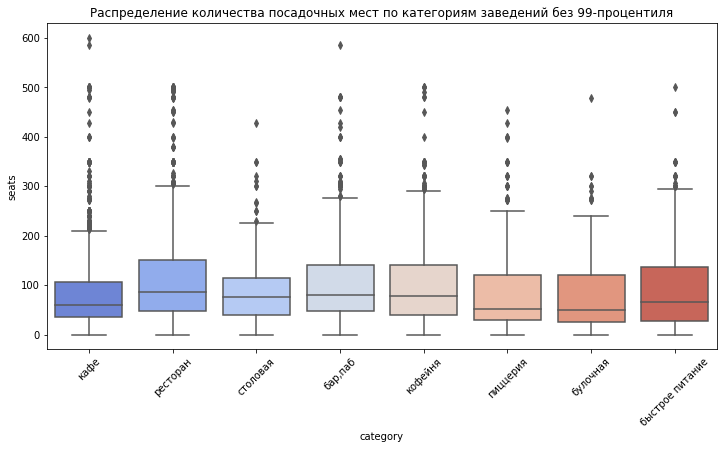

In [40]:
# Построим распределение количества мест по катгориям 
plt.figure(figsize=(12,6))
sns.boxplot(x='category', y='seats', data=join_df, palette = 'coolwarm')
plt.title('Распределение количества посадочных мест по категориям заведений')
plt.xticks(rotation = 45)
plt.show()


# Отфильтруем данные по 99 процентилю
quantile_filter_seats = join_df[join_df['seats']<join_df['seats'].quantile(0.99)]

# Построим распределение количества мест по катгориям без учета данных за пределами 99 процентиля
plt.figure(figsize=(12,6))
sns.boxplot(x='category', y='seats', data=quantile_filter_seats, palette='coolwarm')
plt.title('Распределение количества посадочных мест по категориям заведений без 99-процентиля')
plt.xticks(rotation = 45)
plt.show()

По графику видим, что медианное значение варьируется в зависимости от категории заведения. Наибольшие значения - у ресторанов (86 мест), бары и пабы (82 места). Наименьшая медиана у булочных (55 мест).
Это свидетельствует о разных моделях обслуживания: рестораны и бары ориентированы на поток поситителей и болшее пространство, пицерии и булочные часто работают в формате "на вынос" и буструю посадку.

Общий вывод:

Типичные заведения общественного питания в Москве - это объекты на 60-90 пасадочных мест. У ресторанов и баров - повышенные значения, у кафе и фастфудов - умеренные, а у булочных и пиццри- минимальные. Предположительная причина выбросов связана с неточностью данных, но также возможно наличие крупных заведений в выборке. 
После очистки столбца seats, данные можно будет использовать для последующео анализа факторов влияющих на рейтин. 

---

### Исследуем рейтинг заведений

Визуализируем распределение средних рейтингов по категориям заведений. 

In [41]:
# Средний рейтинг заведений по категориям 
avg_rating = join_df['rating'].mean()
rating_by_category =( join_df.groupby('category')['rating'].mean().sort_values(ascending = False))

print('Средний рейтинг заведений', avg_rating.round(2), '\n')
print('Средний рейтинг заведений по категориям', '\n', rating_by_category.round(2))

Средний рейтинг заведений 4.23 

Средний рейтинг заведений по категориям 
 category
бар,паб            4.39
пиццерия           4.30
ресторан           4.29
кофейня            4.28
булочная           4.27
столовая           4.21
кафе               4.12
быстрое питание    4.05
Name: rating, dtype: float32


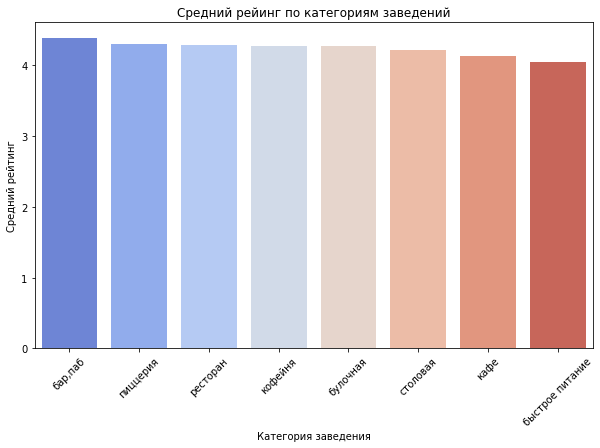

In [42]:
# Визуализация распределения 
plt.figure(figsize = (10,6))
sns.barplot(x=rating_by_category.index, y=rating_by_category.values, palette='coolwarm')

plt.title ('Средний рейинг по категориям заведений')
plt.ylabel('Средний рейтинг')
plt.xlabel('Категория заведения')
plt.xticks (rotation = 45)

plt.show()

В среднем рейтинги заведений по Москве близки друг к другу и не показывают существенных различий между категориями.

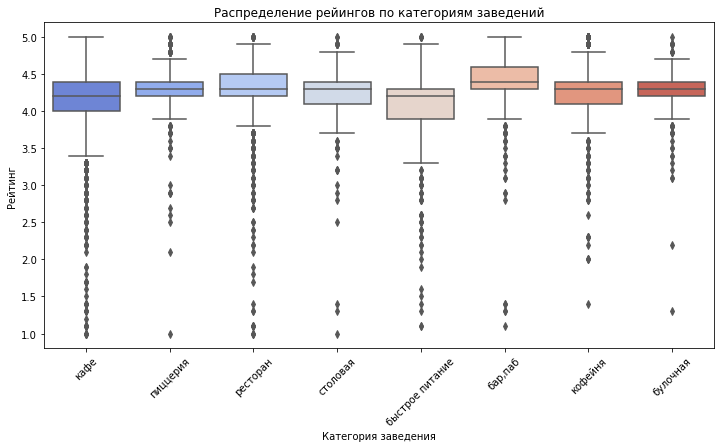

In [43]:
# Ящик с усами
plt.figure(figsize=(12,6))
sns.boxplot(x='category', y='rating', data = join_df, palette = 'coolwarm')

plt.title ('Распределение рейингов по категориям заведений')
plt.ylabel('Рейтинг')
plt.xlabel('Категория заведения')
plt.xticks (rotation = 45)

plt.show()

После визуализации распределения рейтингов по категориям видно, что среднее значение рейтингов находится в достаточно узком диапазоне от 4,0 до 4,4, что говорит о стабильно высоком уровне удовлетворенности клиентов во всех типах заведений. Встречаются значения с крайне низким или наоборот с идиальным рейтингом, но такие оценки естественные, могут быть обусловлены восприятием клиента

- Наиболее высокие рейтинги у пекарен, кафеен, булочных - это можно объяснить более камерной атмосферой, такие типы заведений часто делают акцент на сервис и качество продукта.
- Рестораны и пиццерии также демонстрируют хорошие показатели, но распределение у них более широкое - присутствует больше как хороших, так и плохих оценок. Это может быть из-за разнообразия форматов и уровней обслуживания.
- Столовые и сети быстрого питания имеют рейтинги чуть ниже. Вероятно, это связано с конвейерным типом приготавления узкого ассортимента блюд. В этих типах акцент сделан на скорость обслуживания.



In [44]:
# Рейтинг по округам
rating_by_district = (join_df.groupby('district')['rating'].mean().sort_values(ascending=False))
print(rating_by_district.round(2))

district
центральный административный округ         4.38
северный административный округ            4.24
северо-западный административный округ     4.21
южный административный округ               4.18
западный административный округ            4.18
восточный административный округ           4.17
юго-западный административный округ        4.17
северо-восточный административный округ    4.15
юго-восточный административный округ       4.10
Name: rating, dtype: float32


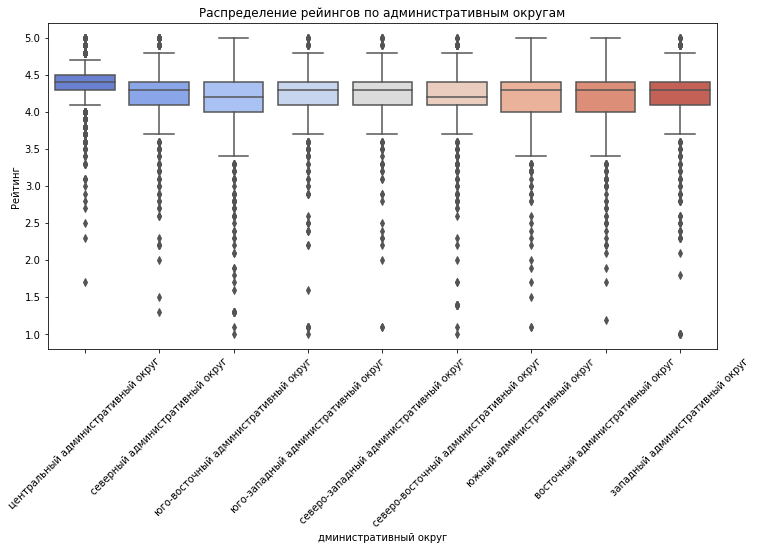

In [45]:
# Ящик с усами
plt.figure(figsize=(12,6))
sns.boxplot(x='district', y='rating', data = join_df, palette = 'coolwarm')

plt.title ('Распределение рейингов по административным округам')
plt.ylabel('Рейтинг')
plt.xlabel('дминистративный округ')
plt.xticks (rotation = 45)

plt.show()

Как и ожидалось лидером рейтинга среди округов является центральный округ, здесь заметно опережение по среднему рейтингу, что может быть связано с более высоким уровнем сервиса. Далее идетсеверный административный округ - отставание небольшое, минимальное среднее значение зафиксировано в юго-восточном округе.

Стоит отметить, что снижение рейтингов от округа к округу является плавным, разница довольно небольшая. Однака прослеживается тенденция: чем ближе к центру, тем выше рейтинг.

Причина такого распределения перекликается с распределением количества заведений по округам, в центре высокая деловая активность, а большое количество заведений наращивает конкуренцию и застявляет улучшать сервис, делать фокус на репутацию.

In [46]:
# Рейтинг по категории+округ
rating_by_cat_dis = join_df.groupby(['district','category'])['rating'].mean()
df_rating_by_cat_dis = rating_by_cat_dis.reset_index()
pivot = df_rating_by_cat_dis.pivot_table(index='district',columns='category', values='rating', aggfunc='mean')

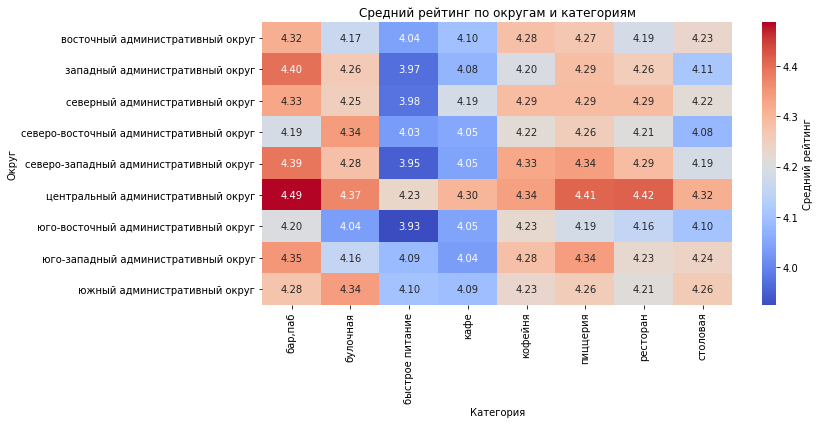

In [47]:
# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label':'Средний рейтинг'}) 
plt.title("Средний рейтинг по округам и категориям")
plt.ylabel("Округ")
plt.xlabel("Категория")
plt.tight_layout()
plt.show()



В разрезе округов и категорий лидирующую позицию по прежнему занимает Центральный округ, особенно в категориях бары и рестораны. Ниже рейтинги в западном и юговосточном округах, хуже всего дела обстаят в  категории быстрого питания.
Рекомендация заказчику: при планировании новых заведений ориентироваться не только на количество конкурентов, но и на средний рейтинг в конкретном районе — это показатель “насыщенности” и удовлетворенности аудитории.


Общий вывод:

Различия между категориями не критичны, но можно разгледеть тенденция - чем более "персонализированный" подход в заведение, тем выше средний рейтинг. Рейтинг можно рассматривать как показатель клиентской лояльности.

---

### Корреляционный анализ

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. 

In [48]:
from phik import resources, report
from phik.report import plot_correlation_matrix

# Явно указываем количественные столбцы
interval_columns = ['rating', 'seats', 'middle_avg_bill', 'middle_coffee_cup']

# Строим матрицу корреляций
phik_corr = join_df[['rating', 'category', 'district', 'chain', 'seats', 
                     'price', 'is_24_7', 'middle_avg_bill', 'middle_coffee_cup']].phik_matrix(interval_cols=interval_columns)

# Выводим корреляции относительно рейтинга
print(phik_corr['rating'].sort_values(ascending=False))


rating               1.000000
price                0.262056
middle_avg_bill      0.218416
category             0.198763
district             0.189453
is_24_7              0.161010
chain                0.119212
seats                0.000000
middle_coffee_cup    0.000000
Name: rating, dtype: float64


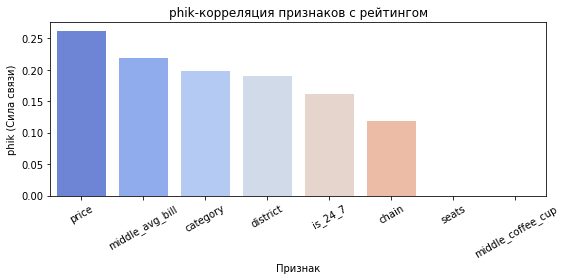

In [49]:
plt.figure(figsize=(8,4))
sns.barplot(x=phik_corr['rating'].drop('rating').sort_values(ascending=False).index,
            y=phik_corr['rating'].drop('rating').sort_values(ascending=False).values, palette='coolwarm')
plt.ylabel('phik (Сила связи)')
plt.xlabel('Признак')
plt.title('phik-корреляция признаков с рейтингом')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Наибольшая корреляция рейтинга наблюдается с ценовой категорией (0.26), средним чеком (0.21) и категорией заведения (0.20). Для остальных признаков коэффициент корреляции снижается с 0.19 до 0. 
Это также можно увидеть на графике. 

Перед тем как перейти к дальнейшему анализу, визуализируем корреляцию с помощью тепловой карты

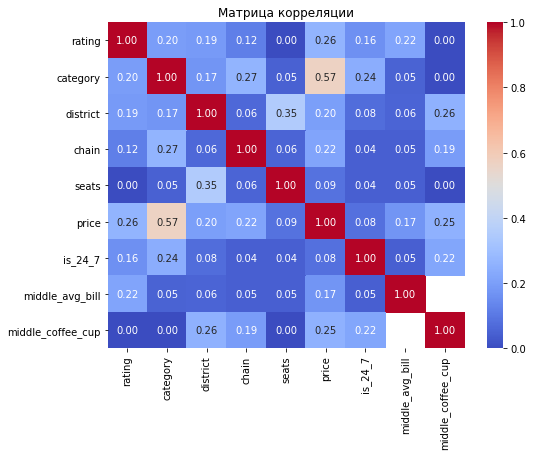

In [50]:
plt.figure(figsize =(8,6))
sns.heatmap(phik_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Матрица корреляции')
plt.show()

Оценивая корреляцию по всем данным, самую сильную связь имуют - price и middle_avg_bill, это объясняется тем, что один столбец получен из данных другого

Умеренная связь между price и category (0.57), так как чаще всего ценовой уровень зависит от типа заведения

Рейтинг слабо коррелирует с остальными признаками, высокие и низкие оценки не завясят напрямую от цен, категории заведения и количества мест, речь идет о совокупности факторов.

In [51]:
# Кодирование price в числовой формат для корреляции Кендалла 

price_order = ['низкие', 'средние', 'выше среднего', 'высокие'] 

# Еще раз приведем к нижнему регистру
join_df['price'] = join_df['price'].str.strip().str.lower()

# Чтобы не было проблем с пропусками оставим только нужные категории
join_df = join_df[join_df['price'].isin(price_order)]

# Добавляем новый столбец и кодируем
join_df['price_num'] = join_df['price'].astype(pd.CategoricalDtype(categories=price_order, ordered=True) ).cat.codes

display(join_df)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7,price_num
8,57ba7a7ffedc472a8e3ba6e033d6a0a5,100ловая,столовая,"москва, графский переулок, 14, корп. 1",северо-восточный административный округ,пн-пт 09:00–17:00,4.4,0,40.0,средние,Средний счёт:250–350 ₽,300.0,NaN,False,1
9,72699eea7724464a8683adf5fd1adc94,100лоффка,столовая,"москва, варшавское шоссе, вл132/2",южный административный округ,пн-пт 09:00–17:30,4.4,0,NaN,низкие,Средний счёт:100–270 ₽,185.0,NaN,False,0
12,5dbefbc3682247dbaf66697cbadfc061,15 kitchen+bar,"бар,паб","москва, пожарский переулок, 15",центральный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.5,0,30.0,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN,False,3
15,94c11fb6fd4d40d9b76b5838c83d9016,16 тонн,"бар,паб","москва, улица арбат, 28/1с1",центральный административный округ,"ежедневно, 12:00–05:00",4.5,0,NaN,высокие,Средний счёт:от 1800 ₽,1800.0,NaN,False,3
16,29fb5c767998463b8fad40f0ac7ee6fa,18 грамм,кофейня,"москва, набережная академика туполева, 15б",центральный административный округ,"пн-пт 08:00–21:00; сб,вс 09:00–21:00",4.4,1,NaN,средние,Цена чашки капучино:100–200 ₽,NaN,150.0,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8396,120a7e7dcb8b4b8a9c57f49673e7a8a1,яуза,ресторан,"москва, улица стромынка, 22",восточный административный округ,"ежедневно, 11:00–00:00",4.4,0,100.0,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN,False,3
8398,5a4a51f61370453790f2e6d4e3ed5b38,ё-ланч,столовая,"москва, новоостаповская улица, 5, стр. 3",юго-восточный административный округ,"ежедневно, 09:00–18:00",4.1,1,NaN,средние,NaN,NaN,NaN,False,1
8399,737086ddefe1497c9ada2ab0892348eb,ёж и устрица,кафе,"москва, гончарная набережная, 9/16с2",центральный административный округ,"пн-чт 12:00–00:00; пт,сб 14:00–02:00; вс 14:00...",4.8,0,NaN,средние,Средний счёт:500–1000 ₽,750.0,NaN,False,1
8400,5747941295c94ac197e38dfa9a2f82cc,ёрш,пиццерия,"москва, липецкая улица, 2, корп. 8",южный административный округ,"ежедневно, 11:30–05:00",4.4,1,120.0,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN,False,2


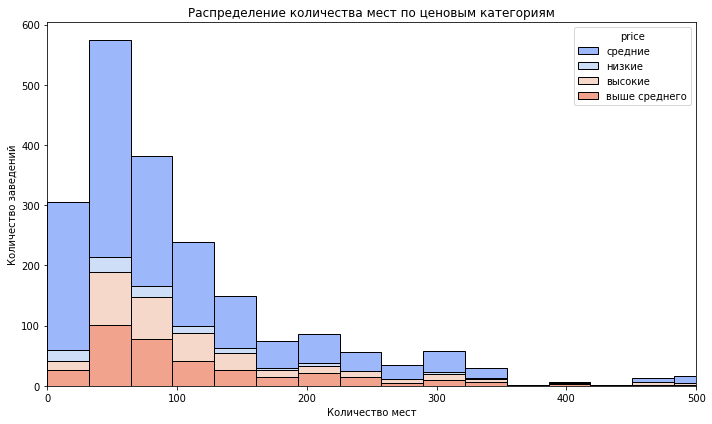

In [52]:
# 5. Гистограмма распределения мест по категориям цен
plt.figure(figsize=(10,6))
sns.histplot(data=join_df, x='seats', hue='price', bins=40, multiple='stack', palette='coolwarm') 
plt.xlim(0, 500)   
plt.title('Распределение количества мест по ценовым категориям') 
plt.xlabel('Количество мест') 
plt.ylabel('Количество заведений')
plt.tight_layout()
plt.show()


Гистограмма распределения мест по цене позволяет понять, что большенство заведений с низкими и средними ценами преобладают на рынке, но высокий рейтинг скорее встречается среди заведений с высокой ценой вне зависимости от размера, тренд к высокому рейтингу не зависит от количества мест, а скорее от ценовой политики

In [53]:
# 4. Корреляция Кендалла (оценивает направление связи рейтинга и цены) 

kendall_corr = join_df[['rating','price_num']].corr(method='kendall')
print('Кендалл корреляция:', kendall_corr.loc['rating','price_num'])

Кендалл корреляция: 0.22800222866607653


Результат корреляции говорит о слабой, но положительной связи.

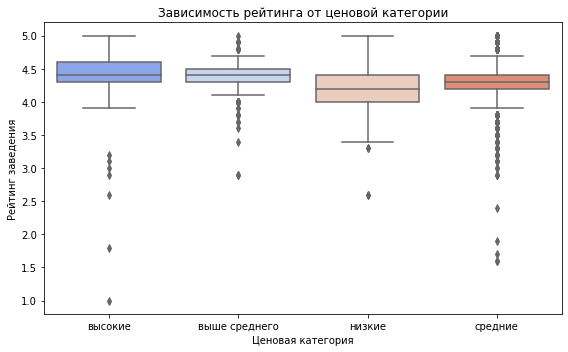

In [54]:
# Визуализация для исследования связи между рейтингом и ценой
plt.figure(figsize=(8,5))
sns.boxplot(x='price', y='rating', palette = 'coolwarm', data=join_df, order=sorted(join_df['price'].dropna().unique()))
plt.ylabel('Рейтинг заведения')
plt.xlabel('Ценовая категория')
plt.title('Зависимость рейтинга от ценовой категории')
plt.tight_layout()
plt.show()


На графике можем заметить нарастание медианного рейтинга при росте ценовой категории, а корреляция положительная и значима, значит связь действительно существует.
Визуализации подтверждают, что более дорогие заведения имеют более высокий рейтинг

Основными закономерностями являются:
- сильная связь рейтинга с ценовыми категориями около 0,25. Это означает, дорогие по цене заведения получают более высокие оценки
- корреляция рейтинга с категорией заведений и географическим расположением умеренная положительна, это говорит о том, что тип ресторана и его местоположение также влияет на восприятие гостей. 
- количество мест, сетевой статус, признак круглосуточности практически не коррелируют с рейтингом.

Корреляция определяет только силу связи, но не не причинно-следственную зависимость. Высокая корреляция между ценой и рейтингом говорит о том, что посетители склонны оценивать дорогие заведения выше, возможно из-забольшего внимания к сервису и атмосфере. Струтурные параметры - размер зала и круглосуточность не оказывают существенного влияния на итоговую оценку.


---

### Выведем Топ-15 популярных сетей в Москве

Для них посчитаем значения среднего рейтинга. 

In [55]:
# Отбираем только сетевые заведения
chain_df= join_df[join_df['chain'] == 1]

# Считаем количество заведений каждой сети + определяем категорию 
top_chains = (chain_df.groupby(['name', 'category']).size().reset_index(name='count').sort_values(by='count', ascending=False))

# Выбираем топ-15 сетей
top_15_chains= top_chains.head(15)

display(top_15_chains)

,name,category,count
539,шоколадница,кофейня,52
240,домино'с пицца,пиццерия,39
302,кулинарная лавка братьев караваевых,кафе,28
124,prime,ресторан,24
465,теремок,ресторан,20
292,кофемания,кофейня,16
151,vasilchukí chaihona №1,ресторан,15
236,джонджоли,ресторан,12
485,хинкальная,ресторан,12
350,мск lounge,"бар,паб",12


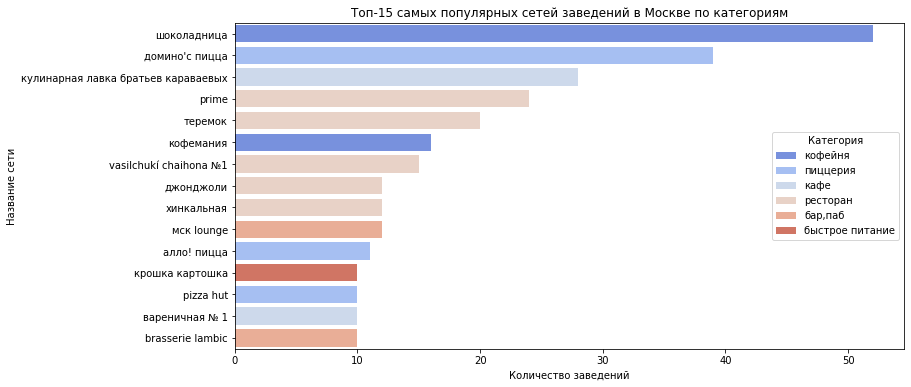

In [56]:
# Отбираем только сетевые заведения
chain_df= join_df[join_df['chain'] == 1]

# Считаем количество заведений каждой сети + определяем категорию 
top_chains = (chain_df.groupby(['name', 'category']).size().reset_index(name='count').sort_values(by='count', ascending=False))

# Выбираем топ-15 сетей
top_15_chains= top_chains.head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_15_chains,
    palette ='coolwarm',
    x='count', y='name',
    hue='category', dodge=False)

plt.title('Топ-15 самых популярных сетей заведений в Москве по категориям') 
plt.xlabel('Количество заведений') 
plt.ylabel('Название сети')
plt.legend(title='Категория')
plt.gca()
plt.show()


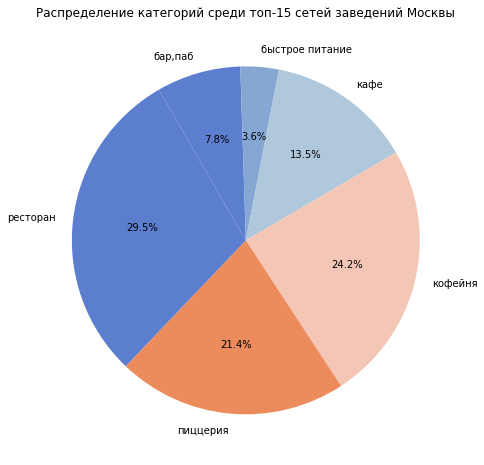

In [57]:
# Круговая диаграмма
top_category_share = top_15_chains.groupby('category')['count'].sum().reset_index()

plt.figure(figsize = (8,8))
plt.pie( top_category_share['count'],
        labels=top_category_share['category'],
        autopct='%1.1f%%', 
        colors=['#5c7ece','#86a7d4','#b0c8db','#f4c6b6','#ec8b5b'],
        startangle = 120,
        counterclock = False) 

plt.title('Распределение категорий среди топ-15 сетей заведений Москвы')
plt.show()

Среди топ-15 сетей Москвы наблюдается явное доминирование заведений категории "кофейня". Это объясняется тем, что подобный форматы легче масштабировать - они требуют меньшей площади, меньше позиций в меню.
Несколько пицццерий занимают первые строки по количеству заведений, это указывает на склонность к франшизам у этой категории заведений.
Также в топ попали рестораны, но их доля значительно  ниже, чаще всего такой формат работает по индивидуальной концепции.
Таким образом, сети кофеен в большей мере формируют основу сетевого рынка общественного питани в Москве, что может указывать на тенденция в потреблении быстрого, доступного и узнаваемого формата

---

### Изучим вариацию среднего чека заведения в зависимости от района Москвы

Проанализируем цены в Центральном административном округе и других районах. 

In [58]:
# Убираем пропуски в нужных колонках
price_df = join_df[['district', 'middle_avg_bill']].dropna()

# Средний чек по районам
district_price_avg = (
    price_df.groupby('district')['middle_avg_bill']
    .mean()
    .reset_index()
    .sort_values(by='middle_avg_bill', ascending=False))

# Медиана 
district_price_med = (
    price_df.groupby('district')['middle_avg_bill']
    .median()
    .reset_index()
    .sort_values(by='middle_avg_bill', ascending=False))

# Объединяем оба датафрейма 
plot_df = pd.merge(
    district_price_avg, 
    district_price_med, 
    on='district', 
    suffixes=('_mean', '_median'))


display(plot_df)


,district,middle_avg_bill_mean,middle_avg_bill_median
0,центральный административный округ,1221.312988,1000.0
1,западный административный округ,1104.071411,1000.0
2,северный административный округ,997.828552,750.0
3,восточный административный округ,924.812500,725.0
4,северо-западный административный округ,906.169495,850.0
5,южный административный округ,904.730469,587.5
6,юго-западный административный округ,845.681824,687.5
7,северо-восточный административный округ,774.906860,575.0
8,юго-восточный административный округ,736.473694,537.5


По данным таблицы видно, что среднее и медианное значение отличается, выбросы могут исказить результаты, по этому для дальнейшего анализа данные необходимо очистить.

На данный момент можно сказать, что лидерами по среднему чеку являются центральный и западный округа. Наименьшее среднее и медианное значение среднего чека набдается в юго-восточном округе.

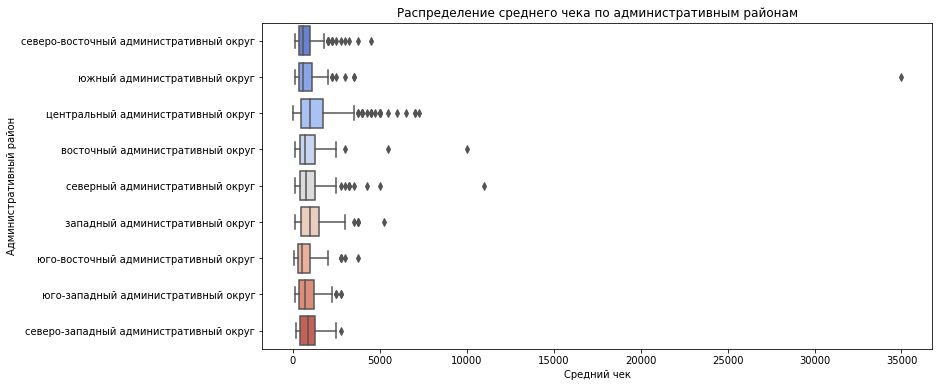

In [59]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=join_df,
    x='middle_avg_bill', y='district',
    palette='coolwarm')

plt.title('Распределение среднего чека по административным районам') 
plt.xlabel('Средний чек') 
plt.ylabel('Административный район')

plt.show()

При анализе вариации по ящику с усами видно, что удаленность от центра влияет на уровень среднего чека, чем ближе - тем выше стоимость. Также отметим наличие выбросов, доходящих до 30 тыс. руб, возможно это рестораны премиального сигмента. 

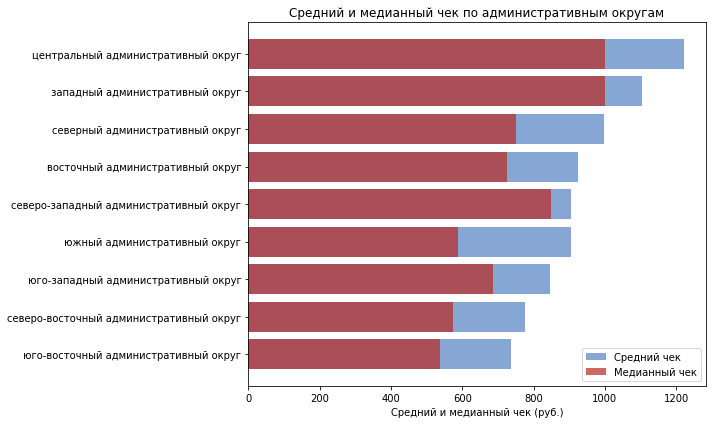

In [60]:
# Упорядочим по среднему чеку

plot_df = plot_df.sort_values(by='middle_avg_bill_mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(plot_df['district'], plot_df['middle_avg_bill_mean'], color='#86a7d4', label='Средний чек') 
plt.barh(plot_df['district'], plot_df['middle_avg_bill_median'], color='#ba2823', alpha=0.7, label= 'Медианный чек') 
plt.xlabel('Средний и медианный чек (руб.)') 
plt.title('Средний и медианный чек по административным округам')
plt.legend()
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()  


Анализ показал, что центральный административный округ, ожидаемо, имеет самый высокий средний чек среди районов города.
Это объясняется высокой стоимостью аренды, высокой турристической активностью и концентрацией кафе и ресторанов среднего и премиум-сигмента. Западный и северный административный округа также показывают относительно высокие чеки, что может быть связано также с высокой деловой активностью и наличаем крупных торговых центров.


In [61]:
# Создаём датафрейм с нужными столбцами и убираем пропуски 
bill_df = join_df[['district', 'category', 'middle_avg_bill']].dropna()

# Шаг 2: Исключаем выбросы по 5 и 95 перцентилю среднего чека 
q_low, q_high = bill_df['middle_avg_bill'].quantile([0.05, 0.95]) 
bill_df_no_outliers = bill_df[
    (price_df['middle_avg_bill'] >= q_low) &
    (price_df['middle_avg_bill'] <= q_high) ]

print(bill_df_no_outliers.info())
display(bill_df_no_outliers.head(5))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2446 entries, 8 to 8401
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   district         2446 non-null   object 
 1   category         2446 non-null   object 
 2   middle_avg_bill  2446 non-null   float32
dtypes: float32(1), object(2)
memory usage: 66.9+ KB
None


,district,category,middle_avg_bill
8,северо-восточный административный округ,столовая,300.0
12,центральный административный округ,"бар,паб",1750.0
15,центральный административный округ,"бар,паб",1800.0
27,северный административный округ,кафе,950.0
31,центральный административный округ,ресторан,2000.0


Произвели фильтрацию выбросов для дальнейшего анализа 

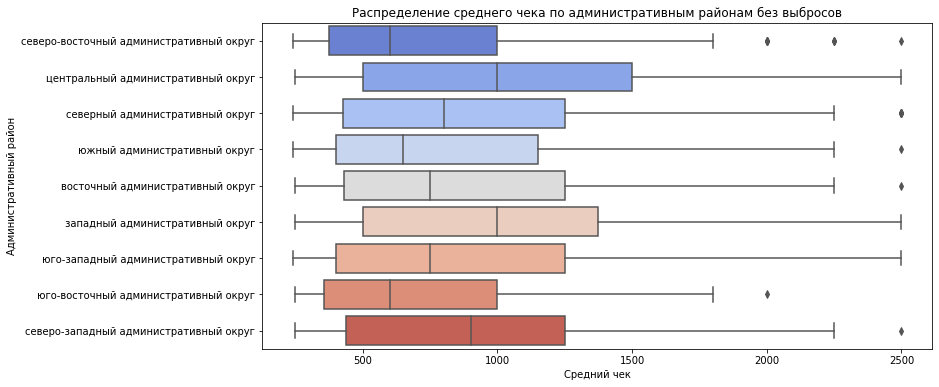

In [62]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=bill_df_no_outliers,
    x='middle_avg_bill', y='district',
    palette='coolwarm')

plt.title('Распределение среднего чека по административным районам без выбросов') 
plt.xlabel('Средний чек') 
plt.ylabel('Административный район')

plt.show()

По анализу вариации ящика с усами без учета  выбросов можно сделать следующие выводы:
- по прежнему центральный район имеею самый высокий средний чек
- следом за центральным районом по размеру среднего чека идет западный округ, демонстрирую сходную тенденцию к более дорогим предложениям

Рынок Москвы в целом демонстрирует концентрированность высоких чеков в центральных районах, что имеет смысл с точки зрения спроса и демографии 

interval columns not set, guessing: ['middle_avg_bill']
                 district  middle_avg_bill
district         1.000000         0.150563
middle_avg_bill  0.150563         1.000000


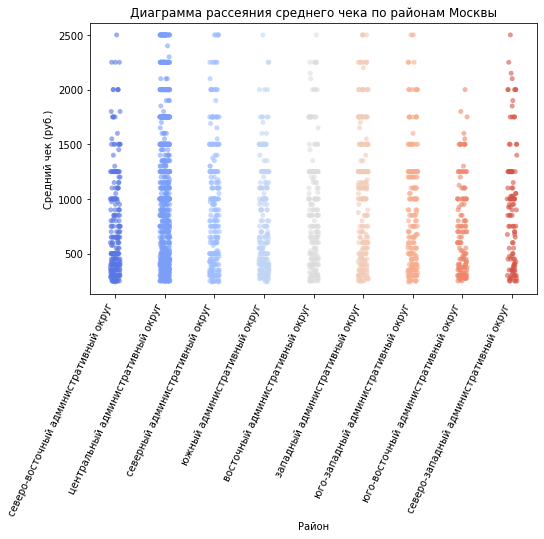

In [63]:
# Корреляция между районом и среднем чеком. Считаем phi_k корреляции
subset = bill_df_no_outliers[['district', 'middle_avg_bill']]
phik_corr = subset.phik_matrix()

print(phik_corr)

# Визуализация
plt.figure(figsize=(8, 5))

sns.stripplot(data=bill_df_no_outliers, 
              x='district', 
              y='middle_avg_bill', 
              alpha=0.6, 
              palette = 'coolwarm',
              jitter=True)
plt.xticks(rotation=65, ha='right')

plt.title('Диаграмма рассеяния среднего чека по районам Москвы')
plt.xlabel('Район')
plt.ylabel('Средний чек (руб.)')

plt.show()


Корреляция между районом и среднем чеком говорит об умеренной, но устойчивой связи. Вывод "чем ближе к центру, тем выше средний чек" подтверждается.

In [64]:
# Делаем сводную таблицу — средний чек по округу и категории 
pivot_bill_df = (
    bill_df_no_outliers.groupby(['district', 'category'])['middle_avg_bill']
    .mean()
    .unstack())

#  ОФОРМЛЯЕМ ТАБЛИЦУ 
styled_table = pivot_bill_df.style.background_gradient(cmap='coolwarm', axis=0)

# Отобразить результат
display(styled_table)


category,"бар,паб",булочная,быстрое питание,кафе,кофейня,пиццерия,ресторан,столовая
district,,,,,,,,
восточный административный округ,1199.347778,355.000000,417.857147,711.041687,445.833344,895.714294,1160.500000,430.363647
западный административный округ,1317.647095,805.000000,500.312500,888.153870,808.928589,866.740723,1301.388916,286.250000
северный административный округ,1386.451660,625.000000,353.266663,739.122803,704.444458,838.513489,1190.000000,358.055542
северо-восточный административный округ,1061.250000,552.500000,487.095245,653.467712,481.250000,733.000000,988.142883,366.428558
северо-западный административный округ,1057.142822,nan,362.500000,838.695679,585.333313,846.750000,1251.000000,291.000000
центральный административный округ,1358.535034,1432.500000,507.820526,801.648926,821.923096,1110.409790,1283.663696,330.540527
юго-восточный административный округ,1043.181763,350.000000,497.500000,566.891907,400.000000,839.500000,888.500000,344.285706
юго-западный административный округ,1030.000000,730.000000,504.000000,637.840881,432.142853,912.049988,1126.835571,322.142853
южный административный округ,1112.963013,525.000000,436.750000,762.978699,642.272705,831.192322,945.394714,311.700012


Вывод по таблице:
- Самые дорогие заведения находятся в Западном и Центральном административных округах — здесь средний чек по большинству категорий выше 1000 ₽.
- Рестораны и бары/пабы стабильно демонстрируют наиболее высокий средний чек во всех округах.
- Столовые и фастфуд ожидаемо имеют самый низкий чек — в среднем от 300 до 500 ₽.
- В Северо-западном округе наблюдается пропуск данных по категории «булочная», что может быть связано с отсутствием достаточного числа заведений этой категории.
- В целом, уровень среднего чека сильно зависит от категории заведения и расположения — центральные и западные районы дороже, чем восточные и южные


---

### Промежуточный вывод


**Вывод по задачам:**
1. Категории заведений. Из всех представленных категорий заведений наиболее распространенными являются кафе и рестораны, булочные и столовые - ниша менее насыщенная. 
2. Распределение по района Москвы. Основная масса заведений сосредоточена в Центральном административном округе, что логично из-за высокой деловой и турристической активности. Район является центром гастронамии, в то время как спальные районы могут стать перспективными для демократичного формата заведений (кофейни, булочные).
3. Сетевые и не сетевые заведения. В целом по городу сетевых заведений гораздо меньше, чем не сетевых. Сетевой формат характерен для стандартизированных заведений - булочных, кофейен, пиццерий. Несетевой формат требует уникальности и авторской подачи.
4. Количество мест в заведении. Медианное количество варьируется от 50 до 90 мест, но есть аномальные значения - заведения с более чем 1200 мест. Связано это скорее с ошибками в данных, но вероятность крупных мест ислючать тоже нельзя. В целом распределение правостороннее.
5. Рейтинг заведений. Средняя оценка находится в диапозоне 4.0-4.5 почти у всех категорий. Самые высокие оценки получают булочные и кофейни, в то время как бары и рестораны демонстрируют большой разброс. В целом посетители оценивают заведения московского общепита достаточно высоко, но  высокий стабильный рейтинг полачают демократичные заведения.
6. Корреляция с рейтингом Наоболее сильную связь с рейтингом умеют ценовые показатели, но корреляцию можно назвать умеренной, сетевой статус показывает слабоположительное влияние на рейтинг.
7. Популярные сети. В топ-15 сетей по количеству заведений вошли в основном кофейни, булочные и пиццерии. Заведения имеют высокий средний рейтинг, что указывает на поддержание и сохранение качества при стандартизированной работе сети. Касательно ресторанов и баров - в топе сетевых заведений они встречаются редко, так как ориентированы на индивидуальный подход.
8. Средний чек по районам. Ожидаемо самый высокий показатель среднего чека в центральном районе, минимальный средний чек зафиксирован в юго-восточном административном округе. Прослеживается четкая закономерность, чем ближе к центру, тем выше средний чек. Отметим, что встречаются крупные выбросы (20-30 тыс. руб), преположительно ошибочные данные, но могут встречаться элитные рестораны с высокими ценами.

## 4. Итоговый вывод и рекомендации



**Общий обзор проделанной работы**

В рамках исследования был проведен анализ заведений общественного питания города Москва. Проект включал обработку данных из нескольких объединенных источников, для изучения структуры заведений, выявления территориальной зависимости среднего чека и популярности категорий заведений, а также влияния факторов на рейтинг и анализа сетевого формата.

Для визуализации использованы различные инструменты анализа данных, что позволило выявить закономерности и аномалии в поведении объектов.

**Ключевые результаты и выводы**

Категории заведений. Наиболее распространённые форматы — кафе, кофейни и рестораны.Меньшую долю занимают столовые и булочные, что отражает специфику московского рынка, ориентированного на повседневное питание и кофе-культуру.

Сетевые и несетевые объекты. На территории города превалируют количество не сетевых заведений. Доля сетевых заведений различается по категориям:
* наиболее распространенными оказались булочные и пиццерии,
* меньше всего сетей — среди ресторанов и баров, где сильнее индивидуальные концепции.
Это указывает на то, что рынок делится на массовый и авторский сегменты, развивающиеся параллельно.

Посадочные места и аномалии. Медианное количество мест различается по типам заведений:
* рестораны и бары — 80–85 мест,
* кофейни и булочные — около 50–55 мест,
* фастфуд и столовые — 60–65 мест.
При этом выявлены выбросы свыше 1200 мест, что, вероятно, связано с ошибками в данных.

Рейтинги заведений. Распределение рейтингов по категориям оказалось достаточно равномерным — медианные значения колеблются около 4.2–4.5, что говорит о высокой конкуренции и относительно стабильном уровне сервиса. Немного выше средние рейтинги у кофеен и булочных, что отражает лояльность посетителей к локальным брендам и небольшим форматам.

Корреляционный анализ. По результатам корреляционной матрицы выявлено:
* наибольшая связь рейтинга — с ценовыми факторами и категорией заведения,
* слабее выражена зависимость от признака «сетевое/несетевое» и «круглосуточное».
С помощью визуализации подтвердили гипотезу, что более дорогие и компактные заведения в среднем имеют чуть более высокий рейтинг.

Популярные сети. Топ-15 сетей формируют значительную долю рынка, среди них — крупные федеральные бренды кофеен и фастфуда.Для каждой сети типична определённая категория (например, кофейни или рестораны быстрого питания), что демонстрирует устойчивость их бизнес-моделей.

Средний чек и районы Москвы. Выявлена отчётливая территориальная зависимость:
* ЦАО — самый высокий средний чек,
* ЮАО, ВАО и ЮВАО — наиболее доступные по цене районы.
Это подтверждает разделение Москвы на премиальные и массовые зоны потребления.

**Рекомендации для заказчика**

В Москве преобладают несетевые заведения - 62%, доля сетевых - 38%. Это говорит о том, что уникальные форматы успешно конкурируют с сетевыми структурами. По этому для масштабирования и узноваемости стоит рассмотреть запуск сетевой концепции.

1. Стратегия развития сети
* Усилить присутствие в спальных районах, где низкая конкуренция и невысокие цены, но растущий спрос на локальные кофейни и пекарни.
* При расширении сети ориентироваться на форматы “кофейня у дома” и “булочная” — наиболее популярные и высокорейтинговые категории.
2. Ценовая политика
* В премиальных районах (ЦАО, ЗАО) можно поддерживать высокий средний чек без потери аудитории.
* В периферийных округах — эффективна стратегия доступных цен при сохранении качества и атмосферы.
3. Концепция заведения
* Малые форматы (до 50 мест) демонстрируют более высокие рейтинги — стоит развивать камерные пространства с персонализированным обслуживанием.
* Для крупных заведений целесообразно внедрять зональную организацию пространства и улучшать сервис.
4. Работа с рейтингом
* Поскольку рейтинг напрямую связан с восприятием цены и комфорта, рекомендуется мониторить отзывы и динамику оценок по каждому району и категории.
* Можно внедрить систему обратной связи с клиентами и использовать данные для корректировки ассортимента и сервиса.
5. Локационная аналитика
* Использовать выявленные закономерности для оптимального выбора локаций новых точек:
    * премиальные бренды — ближе к центру;
    * демократичные форматы — ближе к жилым кварталам и станциям метро.

**Итоговый вывод**

Исследование позволило комплексно оценить рынок общественного питания Москвы и выявить ключевые факторы успеха заведений: локация, формат, ценовая стратегия и размер.Полученные результаты могут служить основой для принятия управленческих решений, расширения сети и формирования продуктовой стратегии в зависимости от целевой аудитории и географии города.